# CV-IPCW-HAL-MLE for Right-Censored Data

This notebook demonstrates **cross-validated IPCW-HAL density estimation** for right-censored data on [0,1].

## Problem Setup

For right-censored data we observe `(T, Δ)` where:
- `T = min(X, C)` — observed time (minimum of true event time and censoring time)
- `Δ = I(X ≤ C)` — event indicator (1 if observed, 0 if censored)

## Method Overview

| Component | Description |
|-----------|-------------|
| **Kaplan-Meier** | Estimates censoring survival function S_c(t) |
| **IPCW Weights** | Inverse probability of censoring weights |
| **HAL-MLE** | Highly Adaptive Lasso density estimator |
| **CV Tuning** | Cross-validation for `basis_order` and `norm_constraint` |

## Notebook Outline

1. **Data Simulation** — Generate right-censored truncated GMM data
2. **Kaplan-Meier** — Estimate censoring survival function
3. **IPCW-HAL Baseline** — Fit initial weighted HAL estimate (manual params)
4. **CV-IPCW-HAL Tuning** — Cross-validated hyperparameter optimization
5. **Evaluation** — Compare methods against true density


In [1]:
# Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction
)

from haldensity.censoring import (
    # Utilities
    KaplanMeier,
    compute_ipcw_weights,
    # Estimators
    RightCensoredIPCWEstimator,
    # Tuners
    RightCensoredOptunaHyperparameterTuner,
    # Metrics
    kl_divergence,
    incomplete_loglik,
)

print("✓ Imports successful")


✓ Imports successful


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Simulation

Generate right-censored data from a **truncated Gaussian Mixture Model** on [0,1]:
- True event times: `X ~ TruncatedGMM` (3 components)
- Censoring times: `C ~ Uniform(0, 1)`
- Observed: `T = min(X, C)` and `Δ = I(X ≤ C)`


In [2]:
# Simulation parameters
np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 1000

# Use the DGP class - Truncated GMM with 3 components
sampler = TruncatedGMM(
    components=[
        {"mean": 0.2, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.5, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.8, "std": 0.05, "lower": 0, "upper": 1}
    ],
    weights=[0.33, 0.34, 0.33]
)

# Generate truncated GMM event times
X_true = sampler.generate_samples(n_samples)

# Generate uniform censoring times
C = rng.uniform(0.0, 1.0, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

# Define true_pdf_fn for evaluation
true_pdf_fn = sampler.compute_density

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")
print(f"Censored observations: {(1 - Delta).sum()}")


Sample size: 1000
Censoring rate: 48.6%
Observed events: 514
Censored observations: 486


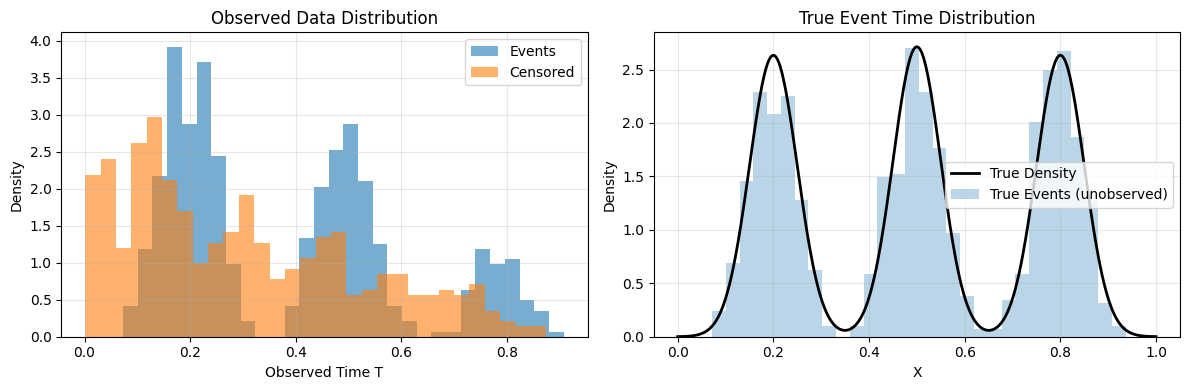

In [3]:
# Visualize data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed data histogram
axes[0].hist(data.loc[data['Delta'] == 1, 'T'], bins=30, alpha=0.6, label='Events', density=True)
axes[0].hist(data.loc[data['Delta'] == 0, 'T'], bins=30, alpha=0.6, label='Censored', density=True)
axes[0].set_xlabel('Observed Time T')
axes[0].set_ylabel('Density')
axes[0].set_title('Observed Data Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True density
grid = np.linspace(0, 1, 500)
true_density = sampler.compute_density(grid)
axes[1].plot(grid, true_density, 'k-', linewidth=2, label='True Density')
axes[1].hist(X_true, bins=30, alpha=0.3, density=True, label='True Events (unobserved)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Density')
axes[1].set_title('True Event Time Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Kaplan-Meier Censoring Survival

Estimate the **censoring survival function** `S_c(t) = P(C > t)` using Kaplan-Meier.


KM estimated at 1000 unique time points
S_c(0.0) = 1.0000
S_c(0.5) = 0.5128
S_c(1.0) = 0.1056


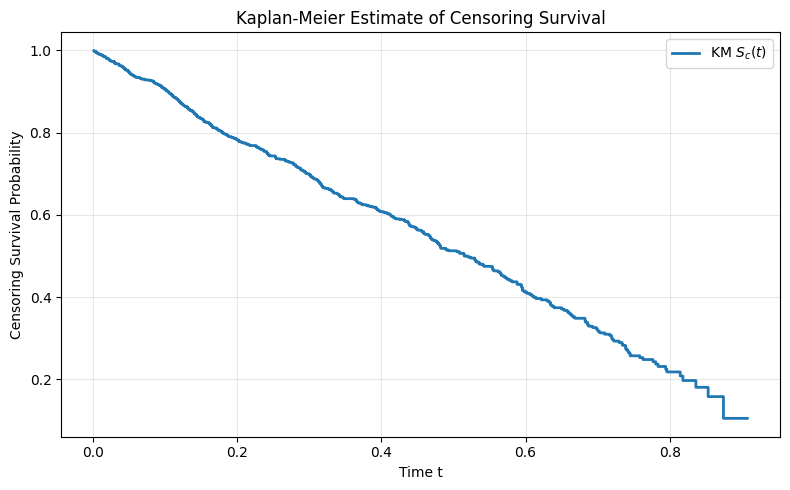

In [4]:
# Fit Kaplan-Meier for censoring survival
km = KaplanMeier()
km.fit(data, time_col="T", delta_col="Delta")

# Get step function for plotting
km_times, km_surv = km.stepwise_survival_()

print(f"KM estimated at {len(km_times)} unique time points")
print(f"S_c(0.0) = {km.predict(0.0):.4f}")
print(f"S_c(0.5) = {km.predict(0.5):.4f}")
print(f"S_c(1.0) = {km.predict(1.0):.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.step(km_times, km_surv, where='post', linewidth=2, label='KM $S_c(t)$')
plt.xlabel('Time t')
plt.ylabel('Censoring Survival Probability')
plt.title('Kaplan-Meier Estimate of Censoring Survival')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Compute IPCW weights
T_vals = np.asarray(data["T"].values, dtype=float)
Delta_vals = np.asarray(data["Delta"].values, dtype=int)

def S_c_predict(t):
    """Predict censoring survival - returns np.ndarray."""
    return np.atleast_1d(km.predict(t))

ipcw_weights = compute_ipcw_weights(T=T_vals, Delta=Delta_vals, S_c_predict=S_c_predict)

print(f"IPCW weights: min={ipcw_weights.min():.4f}, max={ipcw_weights.max():.4f}, mean={ipcw_weights.mean():.4f}")
print(f"Non-zero weights (events): {(ipcw_weights > 0).sum()}")


IPCW weights: min=0.0000, max=9.4697, mean=1.0000
Non-zero weights (events): 514


## 3. IPCW-HAL Baseline (Manual Parameters)

Fit a **weighted HAL density estimator** using only uncensored observations with IPCW weights.

This uses manually chosen hyperparameters as a baseline.


In [6]:
# Fit IPCW-weighted HAL estimator with manual parameters
uncensored_mask = Delta_vals == 1
ipcw_data = pd.DataFrame({"W1": T_vals[uncensored_mask]})
ipcw_weights_unc = ipcw_weights[uncensored_mask]

ipcw_baseline = RightCensoredIPCWEstimator(
    norm_constraint=200,
    basis_order=1,
    solver="ECOS",
)
ipcw_baseline.fit(ipcw_data, sample_weights=ipcw_weights_unc)

# Results
baseline_results = ipcw_baseline.get_results()
print(f"IPCW-HAL Baseline:")
print(f"  norm_constraint: 200")
print(f"  basis_order: 1")
print(f"  Knots selected: {len(baseline_results['grid_points_hal_selected'])}")

# Evaluate
eval_grid = np.linspace(0, 1, 500)
baseline_density = ipcw_baseline.get_density_at_points(eval_grid)
baseline_ll = incomplete_loglik(ipcw_baseline, data, time_col="T", delta_col="Delta")
baseline_kl = kl_divergence(
    true_pdf_fn=true_pdf_fn,
    grid=eval_grid,
    est_density=baseline_density,
)

print(f"\nPerformance:")
print(f"  Log-likelihood: {baseline_ll:.4f}")
print(f"  KL divergence: {baseline_kl:.4f}")


IPCW-HAL Baseline:
  norm_constraint: 200
  basis_order: 1
  Knots selected: 104

Performance:
  Log-likelihood: 24.8393
  KL divergence: 0.0595


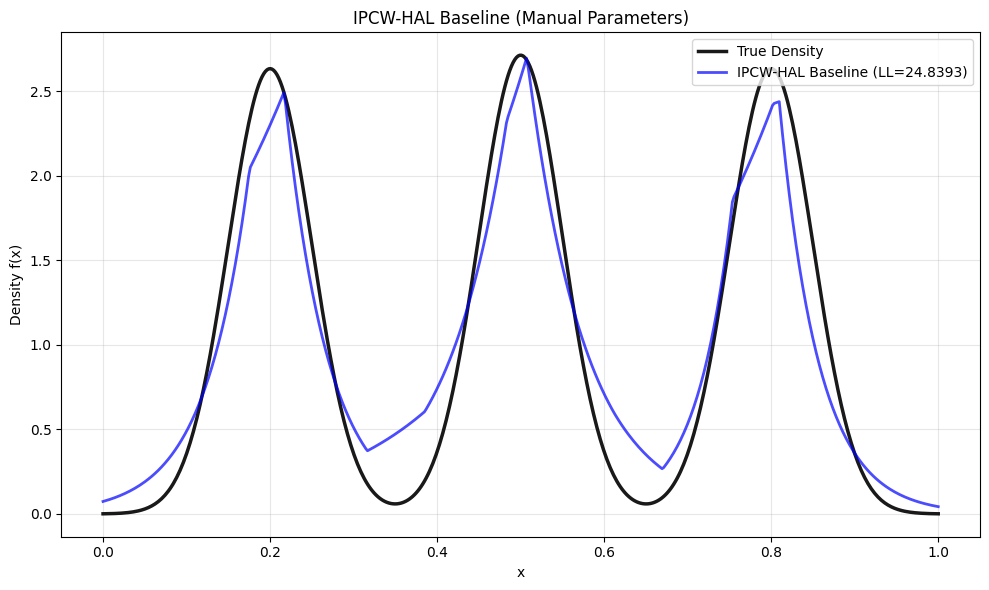

In [7]:
# Plot baseline IPCW-HAL estimate
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True Density', alpha=0.9)
plt.plot(eval_grid, baseline_density, 'b-', linewidth=2, label=f'IPCW-HAL Baseline (LL={baseline_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('IPCW-HAL Baseline (Manual Parameters)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. CV-IPCW-HAL Tuning with Conservative Adjustment

Use **cross-validation** to optimize:
- `basis_order`: Order of HAL basis functions (0 or 1)
- `norm_constraint`: L1 norm constraint

The tuner maximizes incomplete log-likelihood on held-out folds.

### Conservative 1-SE Rule Adjustment

Based on findings from `explore_cv_landscape.py`, CV tends to **oversmooth** (select larger `norm_constraint` than optimal). We implement a conservative selection:

1. **Optuna Search**: Find the CV winner (maximizes CV log-likelihood)
2. **Forward Grid Search**: Search smaller `norm_constraint` values until `CV_LL < max_CV_LL - 1% * SD`
3. **Select**: The smallest `norm_constraint` that still achieves `CV_LL >= max_CV_LL - 1% * SD`

This typically reduces `norm_constraint` and improves KL divergence to the true density.


In [8]:
# CV-IPCW-HAL tuner
from sklearn.model_selection import KFold

np.random.seed(147)
cv_tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    n_grid_points=200,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 100.0, "log": True},
        "basis_order": [0],
    },
    silent=False,
)

print("Starting CV optimization...")
start_time = time.time()
cv_result = cv_tuner.optimize(n_trials=30)
optimization_time = time.time() - start_time

print(f"\n" + "="*50)
print(f"CV Optimization Complete (Optuna)")
print(f"="*50)
print(f"Time: {optimization_time:.2f}s")
print(f"Best params: {cv_result['best_params']}")
print(f"Best CV LL: {cv_result['best_metric_value']:.4f}")


Starting CV optimization...


Optuna CV: 100%|██████████| 30/30 [00:31<00:00,  1.03s/trial, LL=-34.37, best=3.57, order=0] 


CV Optimization Complete (Optuna)
Time: 31.03s
Best params: {'basis_order': 0, 'norm_constraint': 38.00819906301148}
Best CV LL: 3.5748


In [9]:
# Helper function: Compute CV score with fold-level details
def compute_cv_score_with_sd(
    data: pd.DataFrame,
    norm_constraint: float,
    basis_order: int = 0,
    cv_folds: int = 5,
    random_state: int = 42,
    n_grid_points: int = 200,
) -> tuple[float, float, list[float]]:
    """
    Compute CV score and standard deviation for a given norm_constraint.
    
    Returns:
        mean_score: Mean CV log-likelihood across folds
        sd_score: Standard deviation of CV log-likelihood across folds
        fold_scores: List of per-fold scores
    """
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    scores = []
    
    for train_idx, val_idx in kfold.split(data):
        train_df = data.iloc[train_idx].reset_index(drop=True)
        val_df = data.iloc[val_idx].reset_index(drop=True)
        
        try:
            # Fit KM on train
            km_fold = KaplanMeier().fit(train_df, time_col="T", delta_col="Delta")
            
            # Compute IPCW weights
            T_train = np.asarray(train_df["T"].values, dtype=float)
            Delta_train = np.asarray(train_df["Delta"].values, dtype=int)
            w = compute_ipcw_weights(
                T_train, Delta_train, lambda t: np.atleast_1d(km_fold.predict(t))
            )
            
            # Fit on uncensored only
            unc_mask = Delta_train == 1
            df_unc = pd.DataFrame({"W1": T_train[unc_mask]})
            w_unc = w[unc_mask]
            
            est = RightCensoredIPCWEstimator(
                tol=1e-6,
                norm_constraint=norm_constraint,
                n_grid_points=n_grid_points,
                basis_order=basis_order,
                solver="ECOS",
                use_secondary_solver=True,
            ).fit(df_unc, sample_weights=w_unc)
            
            # Evaluate on validation
            score = incomplete_loglik(est, val_df, time_col="T", delta_col="Delta")
            scores.append(score)
        except Exception as e:
            print(f"    Warning: fold failed with {e}")
            scores.append(float("-inf"))
    
    # Filter out failed folds for SD computation
    valid_scores = [s for s in scores if s != float("-inf")]
    mean_score = float(np.mean(valid_scores)) if valid_scores else float("-inf")
    sd_score = float(np.std(valid_scores)) if len(valid_scores) >= 2 else float("nan")
    
    return mean_score, sd_score, scores

print("✓ CV score helper function defined")


✓ CV score helper function defined


In [ ]:
# Conservative Adjustment: Forward Grid Search
# Goal: Find smallest norm_constraint where CV_LL >= max_CV_LL - 5% * SD

print("=" * 70)
print("Conservative 1% SD Rule Adjustment")
print("=" * 70)

# Get best params from Optuna
optuna_best_nc = cv_result['best_params']['norm_constraint']
optuna_best_order = cv_result['best_params']['basis_order']

print(f"Optuna Best norm_constraint: {optuna_best_nc:.4f}")
print(f"Optuna Best basis_order: {optuna_best_order}")

# Step 1: Compute CV score and SD at the Optuna best
print("\nStep 1: Computing CV score and SD at Optuna best...")
optuna_cv_ll, optuna_cv_sd, optuna_fold_scores = compute_cv_score_with_sd(
    data=data,
    norm_constraint=optuna_best_nc,
    basis_order=optuna_best_order,
    cv_folds=5,
    random_state=42,
)

print(f"  CV LL at Optuna best: {optuna_cv_ll:.4f}")
print(f"  CV SD at Optuna best: {optuna_cv_sd:.4f}")
print(f"  Per-fold scores: {[f'{s:.4f}' for s in optuna_fold_scores]}")

# Step 2: Define threshold for 1% SD rule
k_percent = 0.05  # 1% rule
threshold = optuna_cv_ll - k_percent * optuna_cv_sd
print(f"\nStep 2: Threshold = {optuna_cv_ll:.4f} - {k_percent}*{optuna_cv_sd:.4f} = {threshold:.4f}")

# Step 3: Forward grid search to find smaller norm_constraint
max_adjust_steps = 50
step_size_percent = 0.02  # 2% of Optuna best
step_size = step_size_percent * optuna_best_nc

print(f"\nStep 3: Forward grid search")
print(f"  Max adjustment steps: {max_adjust_steps}")
print(f"  Step size: {step_size:.4f} ({step_size_percent*100:.0f}% of {optuna_best_nc:.4f})")
print(f"  Searching norm_constraints from {optuna_best_nc:.4f} down to {optuna_best_nc - max_adjust_steps * step_size:.4f}")

# Track all evaluated points
adjustment_results = [{
    'step': 0,
    'norm_constraint': optuna_best_nc,
    'cv_ll': optuna_cv_ll,
    'cv_sd': optuna_cv_sd,
    'above_threshold': True,
}]

# Forward search: decrease norm_constraint step by step
adjusted_nc = optuna_best_nc
best_conservative_nc = optuna_best_nc
best_conservative_ll = optuna_cv_ll

print(f"\n{'Step':<6} {'NC':>10} {'CV_LL':>10} {'CV_SD':>8} {'Threshold?':>12}")
print("-" * 50)
print(f"{'0':<6} {optuna_best_nc:>10.4f} {optuna_cv_ll:>10.4f} {optuna_cv_sd:>8.4f} {'✓ ABOVE':>12}")

for step in range(1, max_adjust_steps + 1):
    candidate_nc = optuna_best_nc - step * step_size
    
    if candidate_nc <= 0:
        print(f"  Stopping: norm_constraint would be <= 0")
        break
    
    # Compute CV score at candidate
    cand_cv_ll, cand_cv_sd, _ = compute_cv_score_with_sd(
        data=data,
        norm_constraint=candidate_nc,
        basis_order=optuna_best_order,
        cv_folds=5,
        random_state=42,
    )
    
    above_threshold = cand_cv_ll >= threshold
    status = "✓ ABOVE" if above_threshold else "✗ BELOW"
    print(f"{step:<6} {candidate_nc:>10.4f} {cand_cv_ll:>10.4f} {cand_cv_sd:>8.4f} {status:>12}")
    
    adjustment_results.append({
        'step': step,
        'norm_constraint': candidate_nc,
        'cv_ll': cand_cv_ll,
        'cv_sd': cand_cv_sd,
        'above_threshold': above_threshold,
    })
    
    if above_threshold:
        # Update best conservative selection
        best_conservative_nc = candidate_nc
        best_conservative_ll = cand_cv_ll
    else:
        # Stop searching - we've gone below threshold
        print(f"\n  Stopping: CV_LL ({cand_cv_ll:.4f}) dropped below threshold ({threshold:.4f})")
        break

print("-" * 50)
print(f"\n✓ Conservative Selection Complete")
print(f"  Optuna Best NC:       {optuna_best_nc:.4f}")
print(f"  Conservative Best NC: {best_conservative_nc:.4f}")
print(f"  Reduction:            {optuna_best_nc - best_conservative_nc:.4f} ({(optuna_best_nc - best_conservative_nc) / optuna_best_nc * 100:.1f}%)")

# Update cv_result with conservative selection
cv_result['conservative_params'] = {
    'norm_constraint': best_conservative_nc,
    'basis_order': optuna_best_order,
}
cv_result['optuna_params'] = cv_result['best_params'].copy()
cv_result['best_params'] = cv_result['conservative_params']
cv_result['adjustment_results'] = adjustment_results


Conservative 1% SD Rule Adjustment
Optuna Best norm_constraint: 38.0082
Optuna Best basis_order: 0

Step 1: Computing CV score and SD at Optuna best...
  CV LL at Optuna best: 3.5747
  CV SD at Optuna best: 3.8834
  Per-fold scores: ['1.1427', '5.6359', '7.7818', '-2.8259', '6.1389']

Step 2: Threshold = 3.5747 - 0.05*3.8834 = 3.3805

Step 3: Forward grid search
  Max adjustment steps: 40
  Step size: 0.7602 (2% of 38.0082)
  Searching norm_constraints from 38.0082 down to 7.6016

Step           NC      CV_LL    CV_SD   Threshold?
--------------------------------------------------
0         38.0082     3.5747   3.8834      ✓ ABOVE
1         37.2480     3.5746   3.8834      ✓ ABOVE
2         36.4879     3.5747   3.8835      ✓ ABOVE
3         35.7277     3.5745   3.8833      ✓ ABOVE
4         34.9675     3.5746   3.8834      ✓ ABOVE
5         34.2074     3.5746   3.8834      ✓ ABOVE
6         33.4472     3.5746   3.8834      ✓ ABOVE
7         32.6871     3.5747   3.8835      ✓ ABOVE
8   

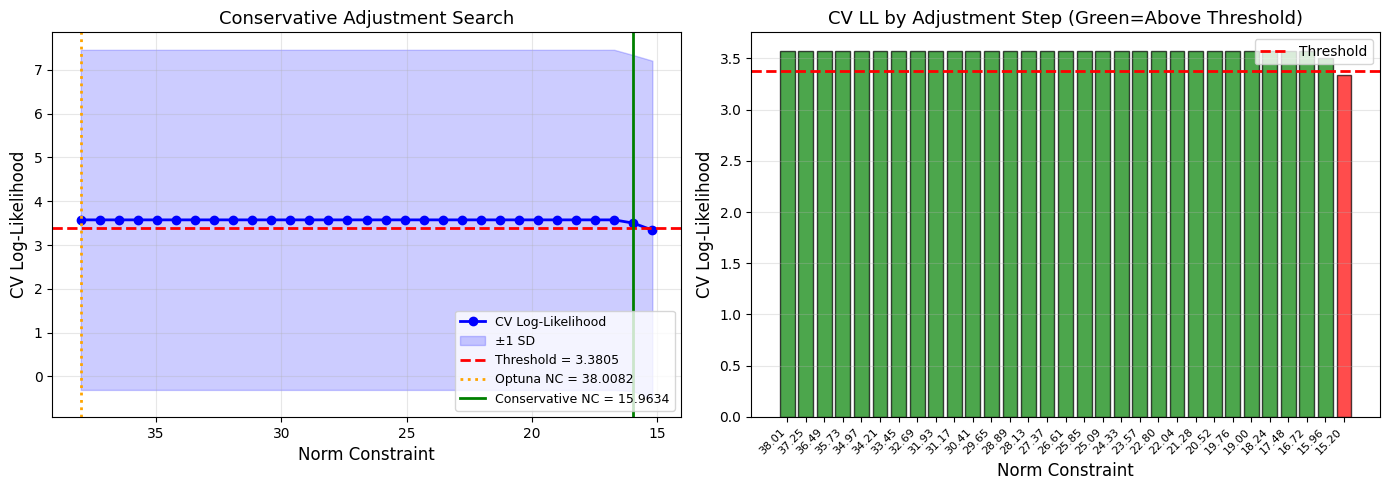

In [11]:
# Visualize the adjustment search
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert results to arrays for plotting
adj_df = pd.DataFrame(adjustment_results)

# Left: CV LL vs norm_constraint during adjustment
ax = axes[0]
ax.plot(adj_df['norm_constraint'], adj_df['cv_ll'], 'b-o', linewidth=2, markersize=6, label='CV Log-Likelihood')
ax.fill_between(
    adj_df['norm_constraint'],
    adj_df['cv_ll'] - adj_df['cv_sd'],
    adj_df['cv_ll'] + adj_df['cv_sd'],
    alpha=0.2, color='blue', label='±1 SD'
)
ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
ax.axvline(optuna_best_nc, color='orange', linestyle=':', linewidth=2, label=f'Optuna NC = {optuna_best_nc:.4f}')
ax.axvline(best_conservative_nc, color='green', linestyle='-', linewidth=2, label=f'Conservative NC = {best_conservative_nc:.4f}')

ax.set_xlabel('Norm Constraint', fontsize=12)
ax.set_ylabel('CV Log-Likelihood', fontsize=12)
ax.set_title('Conservative Adjustment Search', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.invert_xaxis()  # Higher NC on left (where Optuna started)

# Right: Above/below threshold indicator
ax = axes[1]
colors = ['green' if x else 'red' for x in adj_df['above_threshold']]
ax.bar(range(len(adj_df)), adj_df['cv_ll'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold')
ax.set_xticks(range(len(adj_df)))
ax.set_xticklabels([f"{nc:.2f}" for nc in adj_df['norm_constraint']], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Norm Constraint', fontsize=12)
ax.set_ylabel('CV Log-Likelihood', fontsize=12)
ax.set_title('CV LL by Adjustment Step (Green=Above Threshold)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [12]:
# Fit both Optuna and Conservative models on full data
print("=" * 70)
print("Fitting Final Models")
print("=" * 70)

# 1. Optuna Best Model
print("\n1. Optuna Best Model:")
optuna_model = RightCensoredIPCWEstimator(
    norm_constraint=cv_result['optuna_params']['norm_constraint'],
    basis_order=cv_result['optuna_params']['basis_order'],
    solver="ECOS",
)
optuna_model.fit(ipcw_data, sample_weights=ipcw_weights_unc)

optuna_density = optuna_model.get_density_at_points(eval_grid)
optuna_ll = incomplete_loglik(optuna_model, data, time_col="T", delta_col="Delta")
optuna_kl = kl_divergence(
    true_pdf_fn=true_pdf_fn,
    grid=eval_grid,
    est_density=optuna_density,
)
optuna_n_knots = len(optuna_model.get_results()['grid_points_hal_selected'])

print(f"  norm_constraint: {cv_result['optuna_params']['norm_constraint']:.4f}")
print(f"  basis_order: {cv_result['optuna_params']['basis_order']}")
print(f"  Knots selected: {optuna_n_knots}")
print(f"  Log-likelihood: {optuna_ll:.4f}")
print(f"  KL divergence: {optuna_kl:.4f}")

# 2. Conservative Best Model (1% SD Rule)
print("\n2. Conservative Best Model (1% SD Rule):")
conservative_model = RightCensoredIPCWEstimator(
    norm_constraint=cv_result['conservative_params']['norm_constraint'],
    basis_order=cv_result['conservative_params']['basis_order'],
    solver="ECOS",
)
conservative_model.fit(ipcw_data, sample_weights=ipcw_weights_unc)

conservative_density = conservative_model.get_density_at_points(eval_grid)
conservative_ll = incomplete_loglik(conservative_model, data, time_col="T", delta_col="Delta")
conservative_kl = kl_divergence(
    true_pdf_fn=true_pdf_fn,
    grid=eval_grid,
    est_density=conservative_density,
)
conservative_n_knots = len(conservative_model.get_results()['grid_points_hal_selected'])

print(f"  norm_constraint: {cv_result['conservative_params']['norm_constraint']:.4f}")
print(f"  basis_order: {cv_result['conservative_params']['basis_order']}")
print(f"  Knots selected: {conservative_n_knots}")
print(f"  Log-likelihood: {conservative_ll:.4f}")
print(f"  KL divergence: {conservative_kl:.4f}")

# Set conservative as the final best
best_ipcw = conservative_model
cv_density = conservative_density
cv_ll = conservative_ll
cv_kl = conservative_kl

print("\n" + "=" * 70)
print("Comparison: Optuna vs Conservative Selection")
print("=" * 70)
print(f"{'Metric':<25} {'Optuna':>15} {'Conservative':>15} {'Improvement':>15}")
print("-" * 70)
print(f"{'norm_constraint':<25} {cv_result['optuna_params']['norm_constraint']:>15.4f} {cv_result['conservative_params']['norm_constraint']:>15.4f} {cv_result['optuna_params']['norm_constraint'] - cv_result['conservative_params']['norm_constraint']:>+15.4f}")
print(f"{'Model Size (knots)':<25} {optuna_n_knots:>15} {conservative_n_knots:>15} {optuna_n_knots - conservative_n_knots:>+15}")
print(f"{'Log-Likelihood':<25} {optuna_ll:>15.4f} {conservative_ll:>15.4f} {conservative_ll - optuna_ll:>+15.4f}")
print(f"{'KL Divergence':<25} {optuna_kl:>15.4f} {conservative_kl:>15.4f} {optuna_kl - conservative_kl:>+15.4f}")
print("-" * 70)
print(f"✓ Conservative selection achieves {(optuna_kl - conservative_kl) / optuna_kl * 100:.1f}% KL improvement")


Fitting Final Models

1. Optuna Best Model:
  norm_constraint: 38.0082
  basis_order: 0
  Knots selected: 40
  Log-likelihood: 53.7312
  KL divergence: 7.2057

2. Conservative Best Model (1% SD Rule):
  norm_constraint: 15.9634
  basis_order: 0
  Knots selected: 39
  Log-likelihood: 53.7307
  KL divergence: 0.0668

Comparison: Optuna vs Conservative Selection
Metric                             Optuna    Conservative     Improvement
----------------------------------------------------------------------
norm_constraint                   38.0082         15.9634        +22.0448
Model Size (knots)                     40              39              +1
Log-Likelihood                    53.7312         53.7307         -0.0005
KL Divergence                      7.2057          0.0668         +7.1389
----------------------------------------------------------------------
✓ Conservative selection achieves 99.1% KL improvement


In [13]:
# Model size analysis: Optuna vs Conservative vs other multipliers
print("=" * 70)
print("IPCW Model Size Analysis: Optuna vs Conservative Selection")
print("=" * 70)
np.random.seed(42)

optuna_norm = cv_result['optuna_params']['norm_constraint']
conservative_norm = cv_result['conservative_params']['norm_constraint']
best_order = cv_result['conservative_params']['basis_order']

print(f"Optuna norm_constraint: {optuna_norm:.4f}")
print(f"Conservative norm_constraint: {conservative_norm:.4f}")
print(f"Reduction: {optuna_norm - conservative_norm:.4f} ({(optuna_norm - conservative_norm) / optuna_norm * 100:.1f}%)")
print(f"basis_order: {best_order}")
print("-" * 70)

# Use Optuna norm as reference for multipliers
multipliers = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]
results_list = []
model_dict = {}

for mult in multipliers:
    norm_val = mult * optuna_norm
    
    # Fit model at this norm constraint
    model = RightCensoredIPCWEstimator(
        norm_constraint=norm_val,
        basis_order=best_order,
        solver="ECOS",
    )
    model.fit(ipcw_data, sample_weights=ipcw_weights_unc)
    
    # Get model size (number of knots)
    model_results = model.get_results()
    n_knots = len(model_results['grid_points_hal_selected'])
    
    # Evaluate
    model_density = model.get_density_at_points(eval_grid)
    model_dict[mult] = model_density
    model_ll = incomplete_loglik(model, data, time_col="T", delta_col="Delta")
    model_kl = kl_divergence(
        true_pdf_fn=true_pdf_fn,
        grid=eval_grid,
        est_density=model_density,
    )
    
    # Mark if this is close to conservative selection
    is_conservative = abs(norm_val - conservative_norm) < 0.5
    marker = " <-- Conservative" if is_conservative else ""
    
    results_list.append({
        'Multiplier': mult,
        'norm_constraint': norm_val,
        'Model Size (knots)': n_knots,
        'Log-Likelihood': model_ll,
        'KL Divergence': model_kl,
    })
    
    print(f"Multiplier: {mult} | norm_constraint: {norm_val:8.2f} | Knots: {n_knots:4d} | LL: {model_ll:8.4f} | KL: {model_kl:.6f}{marker}")

print("-" * 70)

# Summary table
results_df = pd.DataFrame(results_list)
print("\nSummary Table:")
print(results_df.to_string(index=False))

# Highlight the KL improvement
best_mult_idx = results_df['KL Divergence'].idxmin()
print(f"\n✓ Best KL at multiplier {results_df.loc[best_mult_idx, 'Multiplier']:.1f} (nc={results_df.loc[best_mult_idx, 'norm_constraint']:.2f}), KL={results_df.loc[best_mult_idx, 'KL Divergence']:.6f}")


IPCW Model Size Analysis: Optuna vs Conservative Selection
Optuna norm_constraint: 38.0082
Conservative norm_constraint: 15.9634
Reduction: 22.0448 (58.0%)
basis_order: 0
----------------------------------------------------------------------
Multiplier: 0.2 | norm_constraint:     7.60 | Knots:   26 | LL:  -2.9264 | KL: 0.136977
Multiplier: 0.4 | norm_constraint:    15.20 | Knots:   39 | LL:  53.7306 | KL: 0.063341
Multiplier: 0.6 | norm_constraint:    22.80 | Knots:   40 | LL:  53.7308 | KL: 0.551204
Multiplier: 0.8 | norm_constraint:    30.41 | Knots:   40 | LL:  53.7307 | KL: 3.473398
Multiplier: 1.0 | norm_constraint:    38.01 | Knots:   40 | LL:  53.7312 | KL: 7.205653
Multiplier: 1.2 | norm_constraint:    45.61 | Knots:   39 | LL:  53.7306 | KL: 10.967120
Multiplier: 1.4 | norm_constraint:    53.21 | Knots:   40 | LL:  53.7310 | KL: 14.729163
----------------------------------------------------------------------

Summary Table:
 Multiplier  norm_constraint  Model Size (knots)  Log

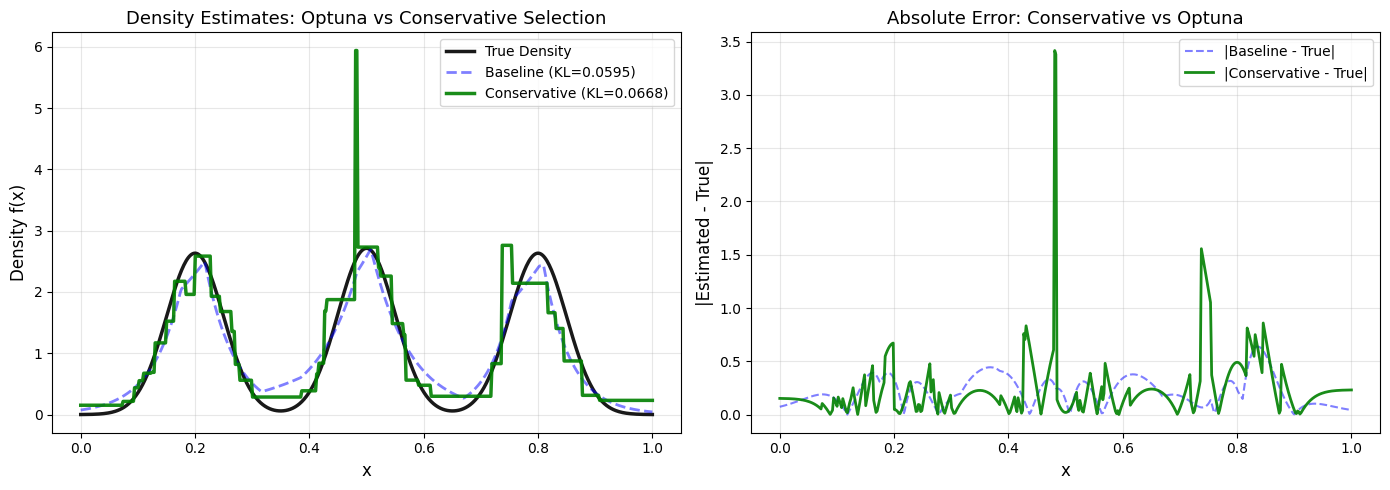

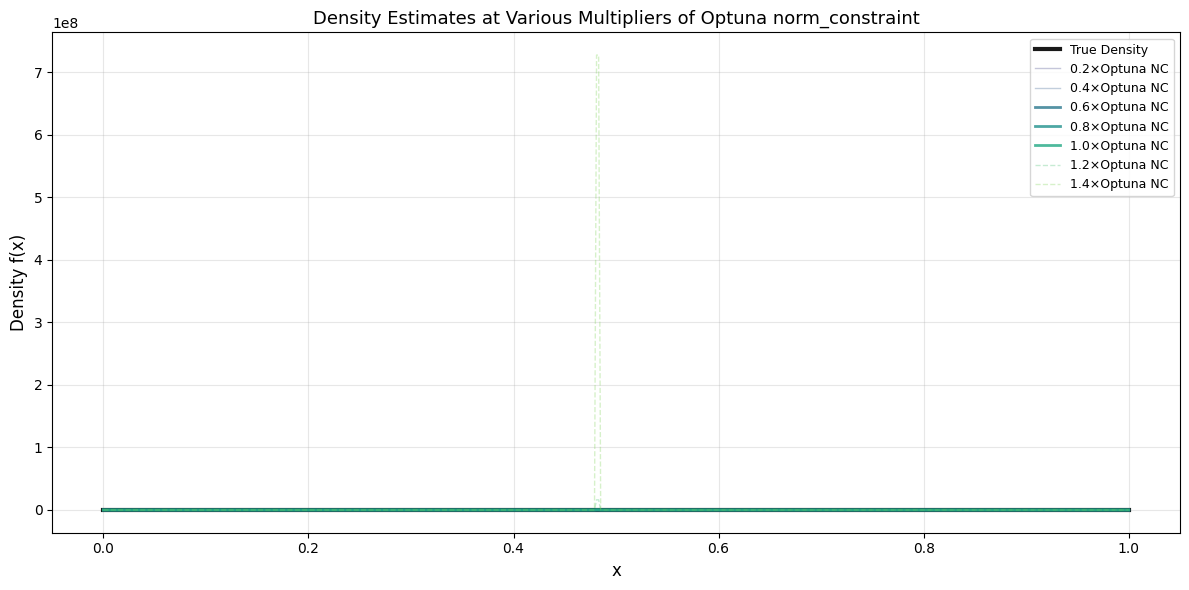

In [17]:
# Plot: Baseline vs Optuna vs Conservative IPCW-HAL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: All estimates comparison
ax = axes[0]
ax.plot(grid, true_density, 'k-', linewidth=2.5, label='True Density', alpha=0.9)
ax.plot(eval_grid, baseline_density, 'b--', linewidth=2, label=f'Baseline (KL={baseline_kl:.4f})', alpha=0.5)
# ax.plot(eval_grid, optuna_density, 'orange', linewidth=2, linestyle='--', label=f'Optuna (KL={optuna_kl:.4f})', alpha=0.7)
ax.plot(eval_grid, conservative_density, 'g-', linewidth=2.5, label=f'Conservative (KL={conservative_kl:.4f})', alpha=0.9)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density f(x)', fontsize=12)
ax.set_title('Density Estimates: Optuna vs Conservative Selection', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Zoomed difference from true
ax = axes[1]
ax.plot(eval_grid, np.abs(baseline_density - true_pdf_fn(eval_grid)), 'b--', linewidth=1.5, label='|Baseline - True|', alpha=0.5)
# ax.plot(eval_grid, np.abs(optuna_density - true_pdf_fn(eval_grid)), 'orange', linewidth=1.5, linestyle='--', label='|Optuna - True|', alpha=0.7)
ax.plot(eval_grid, np.abs(conservative_density - true_pdf_fn(eval_grid)), 'g-', linewidth=2, label='|Conservative - True|', alpha=0.9)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('|Estimated - True|', fontsize=12)
ax.set_title('Absolute Error: Conservative vs Optuna', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Additional plot showing multiplier comparison
plt.figure(figsize=(12, 6))
plt.plot(grid, true_density, 'k-', linewidth=3, label='True Density', alpha=0.9)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(multipliers)))
for i, mult in enumerate(multipliers):
    alpha = 0.3 if mult not in [0.6, 0.8, 1.0] else 0.8
    lw = 1 if mult not in [0.6, 0.8, 1.0] else 2
    linestyle = '-' if mult <= 1.0 else '--'
    plt.plot(eval_grid, model_dict[mult], color=colors[i], linewidth=lw, alpha=alpha, 
             linestyle=linestyle, label=f'{mult}×Optuna NC')

plt.xlabel('x', fontsize=12)
plt.ylabel('Density f(x)', fontsize=12)
plt.title('Density Estimates at Various Multipliers of Optuna norm_constraint', fontsize=13)
plt.legend(fontsize=9, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Summary

Compare baseline (manual parameters) vs CV-tuned IPCW-HAL.


In [15]:
# Summary table: Baseline vs Optuna vs Conservative
print("=" * 80)
print("SUMMARY: CV-IPCW-HAL-MLE with Conservative Adjustment")
print("=" * 80)

results_summary = pd.DataFrame({
    "Method": [
        "IPCW-HAL Baseline (manual)",
        "CV-IPCW-HAL (Optuna)",
        "CV-IPCW-HAL (Conservative 1% SD)",
    ],
    "norm_constraint": [
        200,
        cv_result['optuna_params']['norm_constraint'],
        cv_result['conservative_params']['norm_constraint'],
    ],
    "basis_order": [
        1,
        cv_result['optuna_params']['basis_order'],
        cv_result['conservative_params']['basis_order'],
    ],
    "Log-Likelihood": [baseline_ll, optuna_ll, conservative_ll],
    "KL Divergence": [baseline_kl, optuna_kl, conservative_kl],
})

print(results_summary.to_string(index=False))
print("=" * 80)

print(f"\nImprovement from Conservative vs Optuna:")
print(f"  norm_constraint reduction: {cv_result['optuna_params']['norm_constraint'] - cv_result['conservative_params']['norm_constraint']:.4f} ({(cv_result['optuna_params']['norm_constraint'] - cv_result['conservative_params']['norm_constraint']) / cv_result['optuna_params']['norm_constraint'] * 100:.1f}%)")
print(f"  LL change: {conservative_ll - optuna_ll:+.4f}")
print(f"  KL change: {conservative_kl - optuna_kl:+.4f} (negative = better)")
print(f"  KL improvement: {(optuna_kl - conservative_kl) / optuna_kl * 100:.1f}%")


SUMMARY: CV-IPCW-HAL-MLE with Conservative Adjustment
                          Method  norm_constraint  basis_order  Log-Likelihood  KL Divergence
      IPCW-HAL Baseline (manual)       200.000000            1       24.839309       0.059509
            CV-IPCW-HAL (Optuna)        38.008199            0       53.731182       7.205653
CV-IPCW-HAL (Conservative 1% SD)        15.963444            0       53.730668       0.066772

Improvement from Conservative vs Optuna:
  norm_constraint reduction: 22.0448 (58.0%)
  LL change: -0.0005
  KL change: -7.1389 (negative = better)
  KL improvement: 99.1%


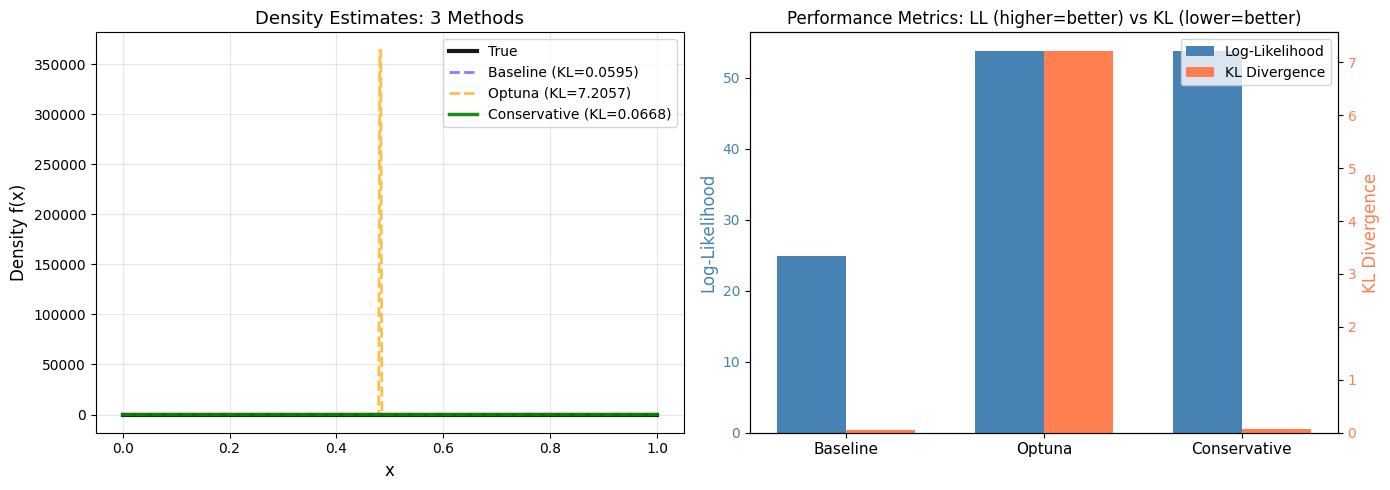

In [16]:
# Final comparison plot: Baseline vs Optuna vs Conservative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Density comparison
axes[0].plot(grid, true_density, 'k-', linewidth=3, label='True', alpha=0.9)
axes[0].plot(eval_grid, baseline_density, 'b--', linewidth=2, label=f'Baseline (KL={baseline_kl:.4f})', alpha=0.5)
axes[0].plot(eval_grid, optuna_density, 'orange', linewidth=2, linestyle='--', label=f'Optuna (KL={optuna_kl:.4f})', alpha=0.7)
axes[0].plot(eval_grid, conservative_density, 'g-', linewidth=2.5, label=f'Conservative (KL={conservative_kl:.4f})', alpha=0.9)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density f(x)', fontsize=12)
axes[0].set_title('Density Estimates: 3 Methods', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: Metric comparison bar chart
methods = ['Baseline', 'Optuna', 'Conservative']
x = np.arange(len(methods))
width = 0.35

ax2 = axes[1]
bars1 = ax2.bar(x - width/2, [baseline_ll, optuna_ll, conservative_ll], width, label='Log-Likelihood', color='steelblue')
ax2.set_ylabel('Log-Likelihood', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax3 = ax2.twinx()
bars2 = ax3.bar(x + width/2, [baseline_kl, optuna_kl, conservative_kl], width, label='KL Divergence', color='coral')
ax3.set_ylabel('KL Divergence', fontsize=12, color='coral')
ax3.tick_params(axis='y', labelcolor='coral')

ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=11)
ax2.set_title('Performance Metrics: LL (higher=better) vs KL (lower=better)', fontsize=12)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


## Key Takeaways

### CV-IPCW-HAL-MLE with Conservative Adjustment Workflow

1. **Estimate censoring survival** using Kaplan-Meier
2. **Compute IPCW weights** for uncensored observations
3. **Optuna CV tuning** to find initial best `norm_constraint`
4. **Conservative 1% SD adjustment**:
   - Compute CV log-likelihood and SD at Optuna best
   - Set threshold = `max_CV_LL - 1% * SD`
   - Forward search for smallest `norm_constraint` ≥ threshold
5. **Fit final model** with conservative parameters

### Why Conservative Adjustment?

Based on empirical findings in `explore_cv_landscape.py`:
- **CV tends to oversmooth**: Maximizing CV log-likelihood often selects larger `norm_constraint` than optimal
- **1% SD rule**: Accepts slight CV performance loss (within 1% of SD) for smaller `norm_constraint`
- **Result**: Better KL divergence to true density, especially under censoring

### When to Use This Approach

- Right-censored data where IPCW performs well
- Settings where CV oversmoothing is a concern
- When you want conservative (less overfit) estimates
- As baseline before EM refinement
